# Task for session2_cont and session3:
## Edge-Preserving Denoising Filters & Feature Matching

**Instructions:**  
**please dont use .py to solve this task, just use tasks2.ipynb and edit the cells.**
- After forking the [SkyXperts-Vision-Course repo](https://github.com/ffathy-tdx/SkyXperts-Vision-Course) on GitHub. (you should have already dont this in the last session & uploaded task1)
- Go to your fork of the repo on GitHub.
- At the top, look for a yellow box that says “This branch is X commits behind…”
- Click the Sync fork or Update branch button.
The new task will show up in your tasks/ folder.  
- Upload your task to your forked repo (like you've done with task1 before)
---

## 1. DoG, LoG, and Edge-Preserving Denoising Filters

**Task:**
- Briefly read the descriptions below, then apply each filter to `'sample.jpg'` (or any test image you choose).
- Compare the results visually and write your observations.

**Background:**
- **DoG (Difference of Gaussian):** Used for edge detection by subtracting two blurred versions of the image (with different Gaussian sigmas).
- **LoG (Laplacian of Gaussian):** Uses a single Gaussian blur followed by Laplacian to highlight regions of rapid intensity change (edges).
- **Edge-Preserving Denoising (Bilateral Filter):** Smooths image while preserving edges (unlike simple Gaussian blur). You've already used this at the end of task1.

---

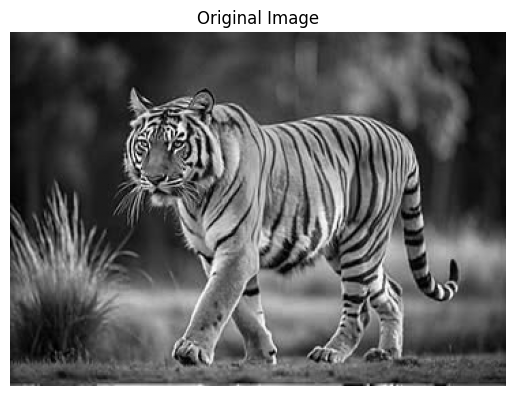

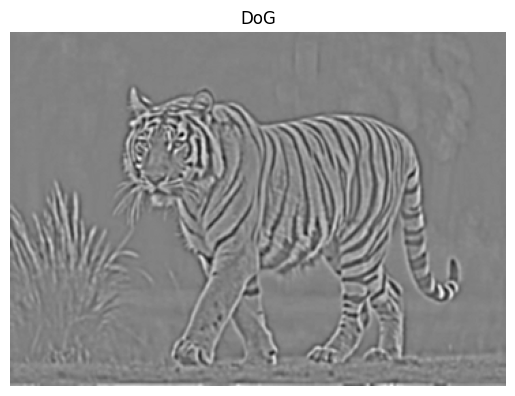

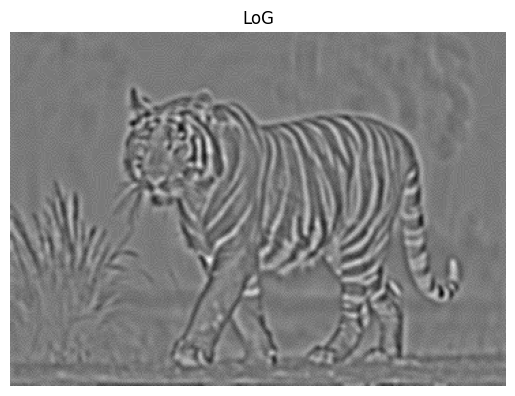

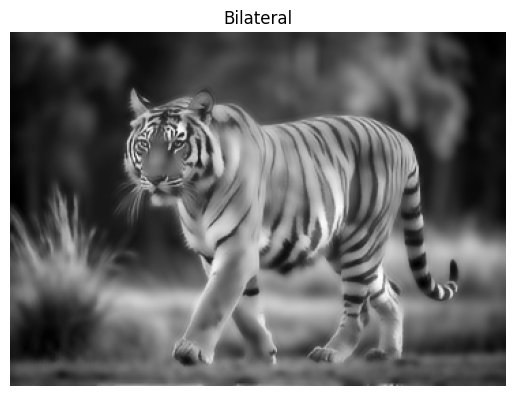

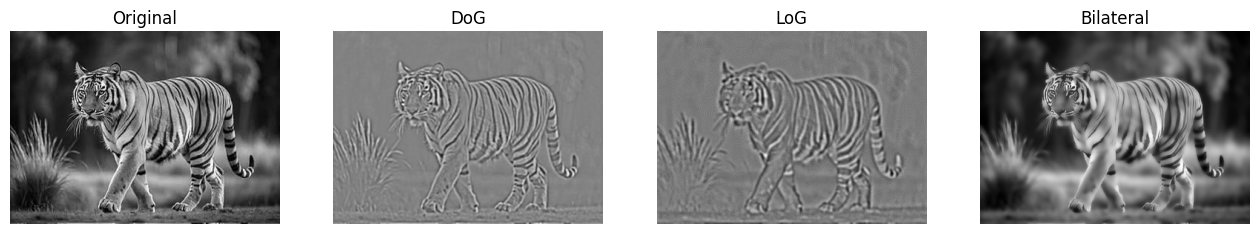

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('sample.jpg', 0)

plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

blur_small = cv2.GaussianBlur(img, (0, 0), 1)

blur_big = cv2.GaussianBlur(img, (0, 0), 2)

blur_small_float = blur_small.astype(float)
blur_big_float = blur_big.astype(float)

dog = blur_small_float - blur_big_float

plt.imshow(dog, cmap='gray')
plt.title('DoG')
plt.axis('off')
plt.show()

blurred = cv2.GaussianBlur(img, (0, 0), 2)

log = cv2.Laplacian(blurred, cv2.CV_64F)

plt.imshow(log, cmap='gray')
plt.title('LoG')
plt.axis('off')
plt.show()

bilateral = cv2.bilateralFilter(img, 9, 75, 75)

plt.imshow(bilateral, cmap='gray')
plt.title('Bilateral')
plt.axis('off')
plt.show()

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(dog, cmap='gray')
plt.title('DoG')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(log, cmap='gray')
plt.title('LoG')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(bilateral, cmap='gray')
plt.title('Bilateral')
plt.axis('off')

plt.show()

**Q1: What differences do you observe between DoG, LoG, and the edge-preserving filter?**

- DoG and LoG give edge maps: mostly gray, with only the edges (stripes and outline) visible.
- Bilateral still looks like the original image, but smoother, with edges kept sharp.

## 2. Keypoints & Descriptors: SIFT vs. ORB

**Task:**
- Detect and plot keypoints on `'sample.jpg'` using SIFT and ORB.
- Compare the number and distribution of detected keypoints.

**Background:**
- **Keypoints:** Distinctive image points (corners/blobs) useful for matching.
- **Descriptors:** Vectors that describe local patches around keypoints for comparison/matching.

---

Successfully prepared sample.jpg and sample2.jpg from your uploaded image!


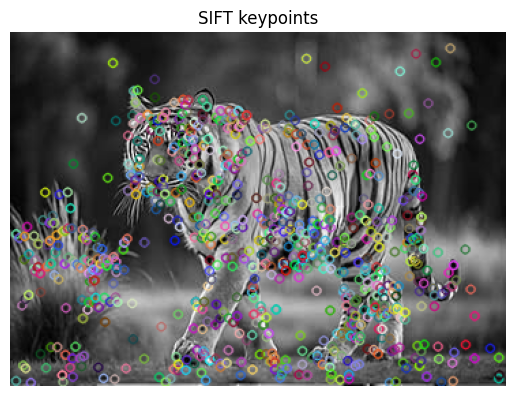

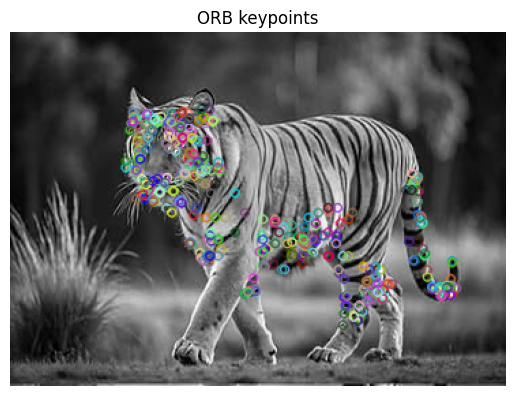

SIFT keypoints: 836
ORB keypoints:  491


In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Fallback: Use user's uploaded image as sample.jpg
uploaded_path = "/content/WhatsApp Image 2026-10-04 at 11.32.06 PM.jpeg"

if os.path.exists(uploaded_path):
    # Load the uploaded image in grayscale and save it as sample.jpg
    img = cv2.imread(uploaded_path, 0)
    cv2.imwrite('sample.jpg', img)

    # Generate a rotated and scaled version to act as sample2.jpg for matching
    rows, cols = img.shape
    M = cv2.getRotationMatrix2D((cols/2, rows/2), 30, 0.8) # Rotate 30 degrees and scale down
    img2 = cv2.warpAffine(img, M, (cols, rows))
    cv2.imwrite('sample2.jpg', img2)
    print("Successfully prepared sample.jpg and sample2.jpg from your uploaded image!")
else:
    raise FileNotFoundError("Please upload your image to '/content/WhatsApp Image 2026-10-04 at 11.32.06 PM.jpeg' or ensure sample.jpg is in the workspace.")

sift = cv2.SIFT_create()

kp_sift, des_sift = sift.detectAndCompute(img, None)

img_sift = cv2.drawKeypoints(img, kp_sift, None)

plt.imshow(img_sift, cmap='gray')
plt.title('SIFT keypoints')
plt.axis('off')
plt.show()

orb = cv2.ORB_create()

kp_orb, des_orb = orb.detectAndCompute(img, None)

img_orb = cv2.drawKeypoints(img, kp_orb, None)

plt.imshow(img_orb, cmap='gray')
plt.title('ORB keypoints')
plt.axis('off')
plt.show()

print("SIFT keypoints:", len(kp_sift))
print("ORB keypoints: ", len(kp_orb))

**Q2: How do the number and distribution of keypoints differ between SIFT and ORB?**

- SIFT finds more keypoints than ORB (ORB is capped at 500 by default).
- SIFT points are spread over the whole image at many scales; ORB points are fewer and mostly on strong corners.

## 3. Feature Matching with Descriptors

**Task:**
- Load a second image (e.g., `'sample2.jpg'`).
- Detect keypoints/descriptors using SIFT or ORB in both images.
- Match the features between the images using BFMatcher or FLANN.
- Plot the top matches.

**Background:**
- **Feature matching** helps recognize objects/scenes or estimate image transformations.

---

Image 1 keypoints: 835
Image 2 keypoints: 566
Number of matches before cleaning: 835
Good matches after cleaning: 355


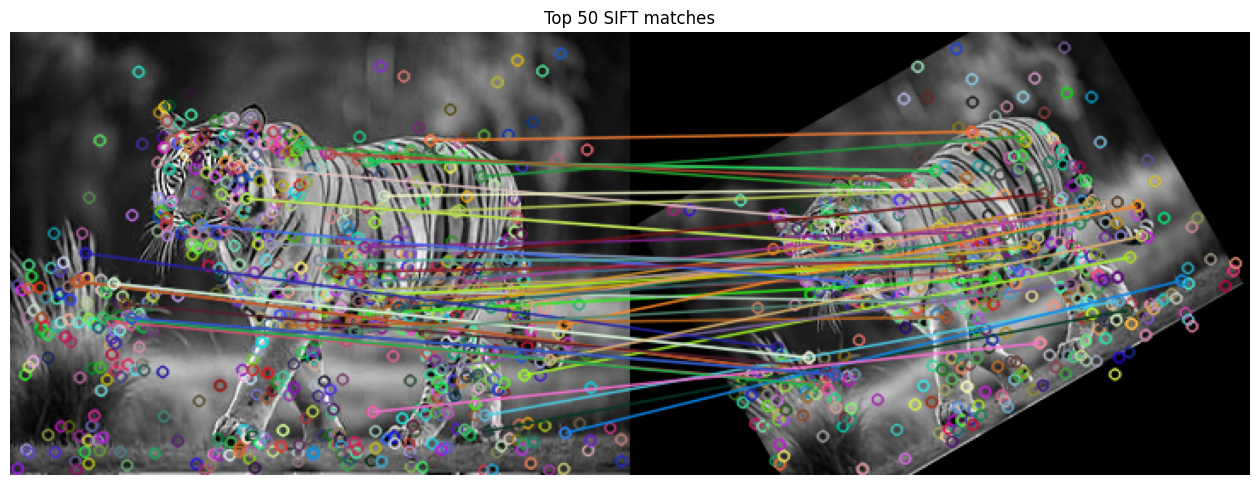

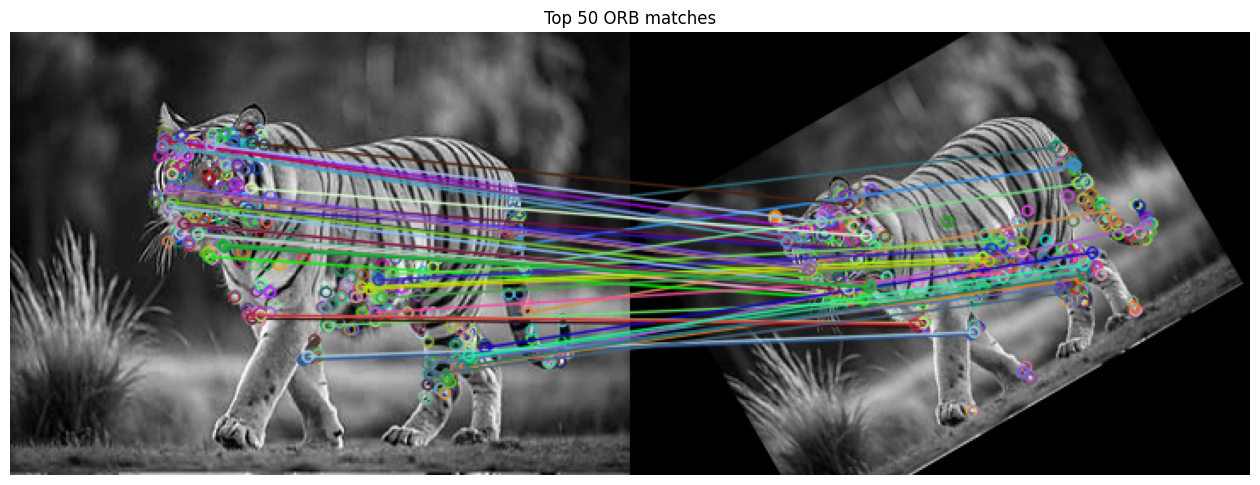

In [15]:
img2 = cv2.imread('sample2.jpg', 0)

kp1, des1 = sift.detectAndCompute(img, None)
kp2, des2 = sift.detectAndCompute(img2, None)

print("Image 1 keypoints:", len(kp1))
print("Image 2 keypoints:", len(kp2))

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

print("Number of matches before cleaning:", len(matches))

good = []

for pair in matches:
    best = pair[0]
    second_best = pair[1]

    if best.distance < 0.75 * second_best.distance:
        good.append(best)

print("Good matches after cleaning:", len(good))

def get_distance(match):
    return match.distance

good = sorted(good, key=get_distance)

top_50 = good[:50]
result = cv2.drawMatches(img, kp1, img2, kp2, top_50, None)

plt.figure(figsize=(16, 8))
plt.imshow(result)
plt.title('Top 50 SIFT matches')
plt.axis('off')
plt.show()

orb = cv2.ORB_create()
kpo1, deso1 = orb.detectAndCompute(img, None)
kpo2, deso2 = orb.detectAndCompute(img2, None)

bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
orb_matches = bf_orb.match(deso1, deso2)

orb_matches = sorted(orb_matches, key=get_distance)

top_50_orb = orb_matches[:50]
result_orb = cv2.drawMatches(img, kpo1, img2, kpo2, top_50_orb, None)

plt.figure(figsize=(16, 8))
plt.imshow(result_orb)
plt.title('Top 50 ORB matches')
plt.axis('off')
plt.show()

**Q3: What do you notice about the feature matches? Are there any mismatches or errors? How might you improve the matching process?**

- Most matches connect the same parts of the tiger despite rotation and scale change.
- Some matches are wrong (similar-looking stripes); ORB makes more mistakes than SIFT.
- Improve with: ratio test tuning, `crossCheck=True`, RANSAC, and denoising (e.g. bilateral) before matching.

**Bonus Task (Optional, for extra credit):**
- Try using different image preprocessing steps *before* edge detection or feature extraction.
    - For example:
        - Add noise to your image (e.g., Gaussian noise, salt-and-pepper noise).
        - Apply a sharpening filter to your image.
    - Then, run DoG, LoG, or any edge-preserving filter and observe the changes.
- **What to do:**
    - Show the results (images/plots) for at least one type of preprocessing + edge detection.
    - Briefly explain:
        - How does noise affect edge maps or keypoints?
        - Does sharpening make features easier or harder to detect/match?

**You can add your code and observations in the cells below.**


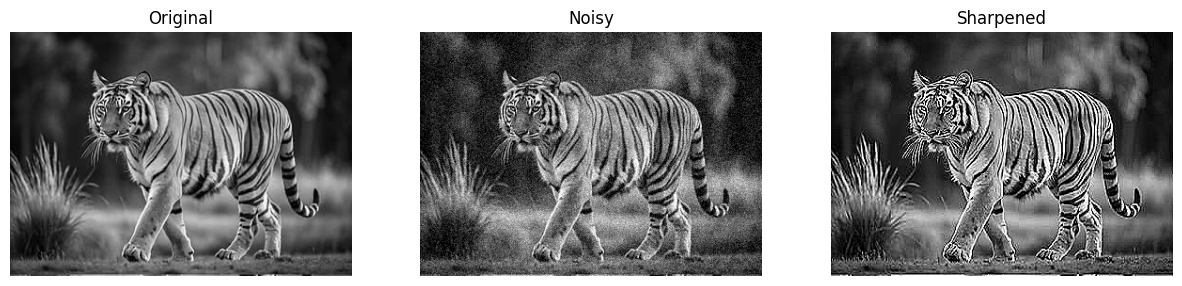

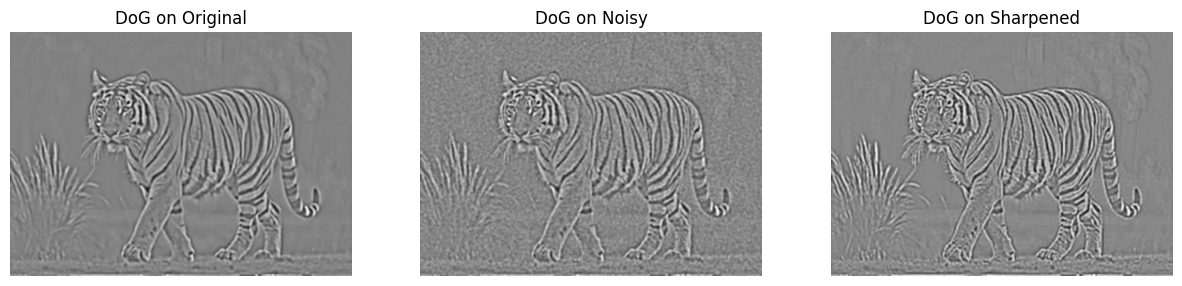

Keypoints - Original:  835
Keypoints - Noisy:     937
Keypoints - Sharpened: 692


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Safely load the image from disk to prevent any NoneType errors
img = cv2.imread('sample.jpg', 0)

if img is None:
    raise FileNotFoundError("sample.jpg is missing in the workspace. Please run the keypoint detection cell first to generate it.")

noise = np.random.normal(0, 20, img.shape)
noisy = img + noise

noisy = np.clip(noisy, 0, 255)
noisy = noisy.astype(np.uint8)

kernel = np.array([[ 0, -1,  0],
                   [-1,  5, -1],
                   [ 0, -1,  0]])
sharp = cv2.filter2D(img, -1, kernel)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noisy, cmap='gray')
plt.title('Noisy')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sharp, cmap='gray')
plt.title('Sharpened')
plt.axis('off')

plt.show()

noisy_small = cv2.GaussianBlur(noisy, (0, 0), 1).astype(float)
noisy_big = cv2.GaussianBlur(noisy, (0, 0), 2).astype(float)
dog_noisy = noisy_small - noisy_big

sharp_small = cv2.GaussianBlur(sharp, (0, 0), 1).astype(float)
sharp_big = cv2.GaussianBlur(sharp, (0, 0), 2).astype(float)
dog_sharp = sharp_small - sharp_big

# Ensure base dog is computed for plotting
blur_small = cv2.GaussianBlur(img, (0, 0), 1).astype(float)
blur_big = cv2.GaussianBlur(img, (0, 0), 2).astype(float)
dog = blur_small - blur_big

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(dog, cmap='gray')
plt.title('DoG on Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(dog_noisy, cmap='gray')
plt.title('DoG on Noisy')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(dog_sharp, cmap='gray')
plt.title('DoG on Sharpened')
plt.axis('off')

plt.show()

sift = cv2.SIFT_create()
kp_sift, _ = sift.detectAndCompute(img, None)
kp_n, des_n = sift.detectAndCompute(noisy, None)
kp_s, des_s = sift.detectAndCompute(sharp, None)
print("Keypoints - Original: ", len(kp_sift))
print("Keypoints - Noisy:    ", len(kp_n))
print("Keypoints - Sharpened:", len(kp_s))

_What are your observations?_

- **Noise:** DoG becomes grainy with many fake edges, and SIFT detects unreliable extra keypoints.
- **Sharpening:** edges look stronger but noise is amplified; SIFT found fewer keypoints here, so it did not help.

## 4. Reflection (Optional)

- What was the most challenging or interesting part of this task for you?
- Any feedback or thoughts?

_Write your reflection here._